In [25]:
from rdkit import Chem
import pandas as pd
from ml_enhance import QuantumFPFileLoader
from IPython.display import display
import numpy as np
from ml_enhance import parallelize

In [76]:
loader = QuantumFPFileLoader("../data/QM9/output")
files = loader.list_output_files()

In [45]:
wanted_properties = ["original_smiles", "output_smiles", "energy", "molecular_dipole_norm", "molecular_polarizability_mean", "homo_lumo_gap", "zero_point_energy", "atomization_energy", "xyz"]

In [47]:
for df in loader.stream_conformer_dataframe(files[0], include_coords=True):
    display(df["original_smiles"])

0    [O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...
Name: original_smiles, dtype: string

In [48]:
def get_min_series(file):
    for df in loader.stream_conformer_dataframe(file, include_coords=True):
        min_series = df.loc[df["energy"].argmin(), wanted_properties]
        return min_series

In [53]:
min_seriess = parallelize(get_min_series, files[:10])

min_df = pd.DataFrame(min_seriess).reset_index()

100%|██████████| 10/10 [00:00<00:00, 484.77it/s]


In [54]:
min_df

,index,original_smiles,output_smiles,energy,molecular_dipole_norm,molecular_polarizability_mean,homo_lumo_gap,zero_point_energy,atomization_energy,xyz
0,0,[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...,[O:1]=[C:2]1[N:3]([H:14])[c:4]2[c:5]([H:15])[c...,-34.129003,1.513984,-99.744189,0.089513,92.688029,5.239994,"[[1, -3.2153719524571107, 0.6129253443797148, ..."
1,0,[Cl:1][c:2]1[c:3]([H:10])[c:4]([H:11])[c:5]([C...,[Cl:1][c:2]1[c:3]([H:10])[c:4]([H:11])[c:5]([C...,-26.123298,0.965182,-95.248037,0.105979,60.507200,3.330826,"[[1, 2.987445614063619, 0.15579633786529493, -..."
2,8,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,[C:1]([C:2]([C:3]([H:19])([H:20])[H:21])([C:4]...,-45.124599,0.496532,-97.621952,0.156378,174.624821,7.142925,"[[1, -3.429155702674601, 1.9092567076259086, 0..."
3,4,[C:1]([c:2]1[c:3]([H:17])[c:4]([H:18])[c:5]([H...,[C:1]([c:2]1[c:3]([H:17])[c:4]([H:18])[c:5]([H...,-39.731606,0.985660,-81.221697,0.130434,123.674411,5.734641,"[[1, -0.4527906185299987, 2.600225770841385, 0..."
4,4,[C:1]([O:2][C:3](=[O:4])[c:5]1[c:6]([H:28])[c:...,[C:1]([O:2][C:3](=[O:4])[c:5]1[c:6]([H:28])[c:...,-72.428696,0.627122,-229.716926,0.064553,141.081602,8.520828,"[[1, 7.083366135884411, 0.9659894063776528, 0...."
5,6,[C:1](/[C:2](=[C:3](\[C:4]([H:22])([H:23])[H:2...,[C:1](/[C:2](=[C:3](\[C:4]([H:22])([H:23])[H:2...,-53.501335,1.174300,-112.663081,0.112836,236.087373,8.771042,"[[1, 3.3074595853243665, 2.438529715517972, -1..."
6,17,[C:1]([C:2](=[C:3]([H:31])[H:32])[C:4](=[O:5])...,[C:1]([C:2](=[C:3]([H:31])[H:32])[C:4](=[O:5])...,-99.896721,1.152904,-87.403675,0.144345,130.206288,7.202134,"[[1, -6.619908711272334, 2.3990925131789096, -..."
7,2,[O:1]=[C:2]1[C:3]([H:28])=[C:4]([H:29])[C:5](=...,[O:1]=[C:2]1[C:3]([H:28])=[C:4]([H:29])[C:5](=...,-74.221860,0.312430,-188.990199,0.059851,186.019595,10.700110,"[[1, -5.336635801966637, 0.2280917670295668, -..."
8,31,[C:1]([C:2]([C:3]([C:4]([C:5]([C:6]([C:7]([C:8...,[C:1]([C:2]([C:3]([C:4]([C:5]([C:6]([C:7]([C:8...,-49.363550,0.725362,-91.713205,0.457517,261.570854,8.618590,"[[1, 7.234192815152152, 1.32029620516832, 0.37..."
9,6,[C:1]([C:2]([C:3]([H:37])([H:38])[H:39])([c:4]...,[C:1]([C:2]([C:3]([H:37])([H:38])[H:39])([c:4]...,-93.618112,1.824956,-223.665810,0.153660,334.200966,14.665924,"[[1, 8.008877745253148, 1.6558793789049837, 0...."


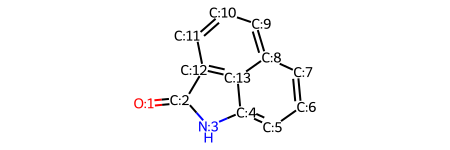

In [61]:
Chem.MolFromSmiles(min_df.loc[0, "output_smiles"])

In [72]:
mol = Chem.MolFromSmiles(min_df.loc[0, "output_smiles"], sanitize=False)
atom_mapping: dict[int, str] = {atom.GetAtomMapNum(): atom.GetSymbol() for atom in mol.GetAtoms()}

geometry = np.array(min_df.loc[0, "xyz"])

In [75]:
atom_list = []
for row in geometry:
    an = int(row[0])
    x, y, z = float(row[1]), float(row[2]), float(row[3])
    sym = atom_mapping.get(an)
    atom_list.append(f"{sym} {x:.8f} {y:.8f} {z:.8f}")

print("\n".join(atom_list))

O -3.21537195 0.61292534 -0.00000017
C -2.00731367 0.58578967 -0.00000005
N -1.19599590 1.71398758 0.00000093
C 0.14903254 1.38749600 -0.00000067
C 1.31373739 2.10637725 0.00000070
C 2.52613223 1.38164199 0.00000043
C 2.59339040 0.01053217 -0.00000017
C 1.40312516 -0.75515536 -0.00000080
C 1.23422676 -2.15695102 0.00000001
C -0.02757381 -2.70803692 0.00000071
C -1.20420020 -1.93532991 0.00000066
C -1.07201247 -0.56912791 -0.00000069
C 0.21838169 -0.01999461 -0.00000138
H -1.56815509 2.64992547 -0.00000168
H 1.33020832 3.18539136 0.00000174
H 3.44555850 1.94918266 0.00000117
H 3.55136283 -0.48729902 -0.00000000
H 2.10350152 -2.79875446 0.00000027
H -0.12599858 -3.78417055 0.00000159
H -2.17212891 -2.41203864 0.00000170


In [ ]:
def build_mol(geometry: np.ndarray, charge: int = 0, spin: int | None = None) -> gto.Mole:
    """Parameters
    ----------
    geometry : np.ndarray, shape (N, 4)
        Columns: [atomic_number, x_Ang, y_Ang, z_Ang]
    charge   : total molecular charge
    spin     : number of unpaired electrons (2S).
               If None (default), spin is detected automatically from the
               electron count — 0 for even, 1 for odd electron systems.
               Pass an explicit integer to override (e.g. spin=2 for triplet).

    Returns:
    -------
    pyscf.gto.Mole (built)
    """
    atom_list = []
    for row in geometry:
        an = int(row[0])
        x, y, z = float(row[1]), float(row[2]), float(row[3])
        sym = atom_mapping.get(an)
        if sym is None:
            raise ValueError(f"Atomic number {an} not in symbol table. Add it to _AN_TO_SYM.")
        atom_list.append(f"{sym} {x:.8f} {y:.8f} {z:.8f}")

    if spin is None:
        spin = detect_spin(geometry, charge)

    mol = gto.Mole()
    mol.atom = "\n".join(atom_list)
    mol.basis = BASIS
    mol.charge = charge
    mol.spin = spin  # 2S (0 = singlet/closed-shell, 1 = doublet, ...)
    mol.unit = "bohr"
    mol.verbose = 3  # set to 0 to silence PySCF output
    mol.build()
    return mol